## 1. Chargement et aperçu des données

Cette section permet de charger le dataset, de vérifier ses dimensions et d’identifier les variables disponibles.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data_path = "../data/raw/data_ex.csv"
df = pd.read_csv(data_path)

In [6]:
df.head()

,Unnamed: 0,gender,Age_client,year,age_of_car_M,Car_power_M,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,...,Insuredcapital_continent_re,appartment,Client_Seniority,Retention,NClaims1,NClaims2,Claims1,Claims2,Types,PolID
0,1,1,84,1,13,90.0,0,1,0,0,...,11.549088,0,16.963723,1,0,0,0.0,0.0,1,1
1,2,1,83,1,0,177.0,0,1,0,1,...,11.506740,0,16.796715,1,0,0,0.0,0.0,1,2
2,3,1,85,1,0,163.0,0,1,0,1,...,11.575080,1,18.603696,1,0,0,0.0,0.0,1,3
3,4,1,85,1,0,90.0,0,1,0,1,...,12.156664,1,20.484600,1,0,0,0.0,0.0,1,4
4,5,1,82,1,20,115.0,0,1,0,1,...,12.369568,1,7.901437,1,0,0,0.0,0.0,1,5


In [7]:
df.shape

(122935, 22)

In [8]:
df.columns.tolist()

['Unnamed: 0',
 'gender',
 'Age_client',
 'year',
 'age_of_car_M',
 'Car_power_M',
 'Car_2ndDriver_M',
 'num_policiesC',
 'metro_code',
 'Policy_PaymentMethodA',
 'Policy_PaymentMethodH',
 'Insuredcapital_content_re',
 'Insuredcapital_continent_re',
 'appartment',
 'Client_Seniority',
 'Retention',
 'NClaims1',
 'NClaims2',
 'Claims1',
 'Claims2',
 'Types',
 'PolID']

In [9]:
print(f'Le dataset contient {df.shape[0]} lignes.')
print(f'Le dataset contient {df.shape[1]} colonnes.')

Le dataset contient 122935 lignes.
Le dataset contient 22 colonnes.


In [10]:
for column in df.columns:
    print(column)

Unnamed: 0
gender
Age_client
year
age_of_car_M
Car_power_M
Car_2ndDriver_M
num_policiesC
metro_code
Policy_PaymentMethodA
Policy_PaymentMethodH
Insuredcapital_content_re
Insuredcapital_continent_re
appartment
Client_Seniority
Retention
NClaims1
NClaims2
Claims1
Claims2
Types
PolID


## 2. Structure et types des variables

Cette section permet d’identifier le type informatique de chaque variable et de vérifier si certaines valeurs sont manquantes.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122935 entries, 0 to 122934
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   122935 non-null  int64  
 1   gender                       122935 non-null  int64  
 2   Age_client                   122935 non-null  int64  
 3   year                         122935 non-null  int64  
 4   age_of_car_M                 122935 non-null  int64  
 5   Car_power_M                  122935 non-null  float64
 6   Car_2ndDriver_M              122935 non-null  int64  
 7   num_policiesC                122935 non-null  int64  
 8   metro_code                   122935 non-null  int64  
 9   Policy_PaymentMethodA        122935 non-null  int64  
 10  Policy_PaymentMethodH        122935 non-null  int64  
 11  Insuredcapital_content_re    122935 non-null  float64
 12  Insuredcapital_continent_re  122935 non-null  float64
 13 

In [12]:
df.isnull().sum()

Unnamed: 0                     0
gender                         0
Age_client                     0
year                           0
age_of_car_M                   0
Car_power_M                    0
Car_2ndDriver_M                0
num_policiesC                  0
metro_code                     0
Policy_PaymentMethodA          0
Policy_PaymentMethodH          0
Insuredcapital_content_re      0
Insuredcapital_continent_re    0
appartment                     0
Client_Seniority               0
Retention                      0
NClaims1                       0
NClaims2                       0
Claims1                        0
Claims2                        0
Types                          0
PolID                          0
dtype: int64

In [13]:
total_missing = df.isnull().sum().sum()
print(f'Nombre total de valeurs manquantes dans le dataset : {total_missing}')

Nombre total de valeurs manquantes dans le dataset : 0


## 3. Analyse des doublons et des identifiants

Cette section vérifie la présence de lignes dupliquées et étudie l’unicité des identifiants des contrats.

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
number_of_duplicates = df.duplicated().sum()
print(f"Nombre de lignes completement dupliques : {number_of_duplicates}")

Nombre de lignes completement dupliques : 0


In [16]:
df["Unnamed: 0"].head()

0    1
1    2
2    3
3    4
4    5
Name: Unnamed: 0, dtype: int64

In [17]:
df["Unnamed: 0"].nunique()

122935

In [18]:
df["Unnamed: 0"].head(10).tolist()

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

### Observation sur `Unnamed: 0`

La variable `Unnamed: 0` correspond à un ancien index enregistré dans le fichier CSV.  
Elle ne contient aucune information utile pour l’analyse ou la prédiction et sera supprimée pendant le nettoyage.

In [19]:
df["PolID"].nunique()

40284

In [21]:
number_of_rows = df.shape[0]
number_of_policies = df['PolID'].nunique()

print(f"nombre d'observations : {number_of_rows}")
print(f"Nombre de contrats différents : {number_of_policies}")


nombre d'observations : 122935
Nombre de contrats différents : 40284


In [20]:
rows_per_policy = df.groupby("PolID").size()

rows_per_policy.head()

PolID
1    5
2    2
3    5
4    5
5    4
dtype: int64

In [22]:
rows_per_policy.describe()

count    40284.000000
mean         3.051708
std          1.621888
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          5.000000
dtype: float64

In [23]:
rows_per_policy.value_counts().sort_index()

1    10466
2     7313
3     5461
4     3760
5    13284
Name: count, dtype: int64

In [24]:
policy_year_duplicates = df.duplicated(
    subset=["PolID", "year"]
).sum()

print(
    f"Nombre de doublons pour la combinaison PolID-year : "
    f"{policy_year_duplicates}"
)

Nombre de doublons pour la combinaison PolID-year : 0


In [26]:
subset=["PolID", "year"]

### Conclusion sur les identifiants

`PolID` n’est pas unique, car un même contrat peut être observé pendant plusieurs années.  
En revanche, la combinaison `PolID`–`year` est unique.

Le dataset possède donc une structure longitudinale : une ligne représente un contrat observé pendant une année donnée.

`PolID` sera conservé pour suivre les contrats dans le temps, mais ne sera pas utilisé directement comme variable explicative du modèle.

## 4. Analyse statistique initiale

Cette section présente les principales statistiques descriptives des variables numériques afin d’identifier leurs ordres de grandeur et leurs valeurs potentiellement atypiques.

In [39]:
df.describe()

,Unnamed: 0,gender,Age_client,year,age_of_car_M,Car_power_M,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,...,Insuredcapital_continent_re,appartment,Client_Seniority,Retention,NClaims1,NClaims2,Claims1,Claims2,Types,PolID
count,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,...,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000,122935.000000
mean,61468.000000,0.778224,59.665856,2.456835,8.849612,111.532338,0.138496,0.810550,0.163591,0.770684,...,11.480258,0.629422,10.265215,0.761695,0.029772,0.034148,26.408765,7.938920,1.051613,20079.288518
std,35488.422009,0.415443,12.948591,1.352461,6.214193,44.413744,0.345421,0.391867,0.369905,0.420395,...,0.917154,0.482962,5.078371,0.426048,0.203021,0.194166,558.955008,177.822212,0.293080,11729.190397
min,1.000000,0.000000,18.000000,1.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,5.736669,0.000000,5.002053,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,30734.500000,1.000000,50.000000,1.000000,4.000000,82.000000,0.000000,1.000000,0.000000,1.000000,...,11.180437,0.000000,6.579055,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9799.000000
50%,61468.000000,1.000000,59.000000,2.000000,9.000000,105.000000,0.000000,1.000000,0.000000,1.000000,...,11.556533,1.000000,8.049281,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,20087.000000
75%,92201.500000,1.000000,70.000000,3.000000,13.000000,130.000000,0.000000,1.000000,0.000000,1.000000,...,12.007364,1.000000,12.859685,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,30221.000000
max,122935.000000,1.000000,95.000000,5.000000,68.000000,560.000000,1.000000,1.000000,1.000000,1.000000,...,15.364570,1.000000,44.706366,1.000000,6.000000,4.000000,109720.710000,27279.820000,4.000000,40284.000000


In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,122935.0,61468.000000,35488.422009,1.000000,30734.500000,61468.000000,92201.500000,122935.000000
gender,122935.0,0.778224,0.415443,0.000000,1.000000,1.000000,1.000000,1.000000
Age_client,122935.0,59.665856,12.948591,18.000000,50.000000,59.000000,70.000000,95.000000
year,122935.0,2.456835,1.352461,1.000000,1.000000,2.000000,3.000000,5.000000
age_of_car_M,122935.0,8.849612,6.214193,0.000000,4.000000,9.000000,13.000000,68.000000
Car_power_M,122935.0,111.532338,44.413744,4.000000,82.000000,105.000000,130.000000,560.000000
Car_2ndDriver_M,122935.0,0.138496,0.345421,0.000000,0.000000,0.000000,0.000000,1.000000
num_policiesC,122935.0,0.810550,0.391867,0.000000,1.000000,1.000000,1.000000,1.000000
metro_code,122935.0,0.163591,0.369905,0.000000,0.000000,0.000000,0.000000,1.000000
Policy_PaymentMethodA,122935.0,0.770684,0.420395,0.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
unique_values = df.nunique().sort_values()
unique_values

gender                              2
num_policiesC                       2
Car_2ndDriver_M                     2
Retention                           2
appartment                          2
Policy_PaymentMethodH               2
Policy_PaymentMethodA               2
metro_code                          2
Types                               4
year                                5
NClaims2                            5
NClaims1                            7
age_of_car_M                       40
Age_client                         75
Car_power_M                       281
Claims1                           900
Claims2                          1883
Client_Seniority                 6213
Insuredcapital_content_re       20041
Insuredcapital_continent_re     25065
PolID                           40284
Unnamed: 0                     122935
dtype: int64

In [42]:
variable_summary = pd.DataFrame({
    "type_python": df.dtypes,
    "Nombre_valeurs_uniques": df.nunique(),
    "Nombre_valeurs_manquantes": df.isnull().sum()
})
variable_summary

,type_python,Nombre_valeurs_uniques,Nombre_valeurs_manquantes
Unnamed: 0,int64,122935,0
gender,int64,2,0
Age_client,int64,75,0
year,int64,5,0
age_of_car_M,int64,40,0
Car_power_M,float64,281,0
Car_2ndDriver_M,int64,2,0
num_policiesC,int64,2,0
metro_code,int64,2,0
Policy_PaymentMethodA,int64,2,0


In [43]:
binary_columns = [
    column
    for column in df.columns
    if df[column].nunique() == 2
]

binary_columns


['gender',
 'Car_2ndDriver_M',
 'num_policiesC',
 'metro_code',
 'Policy_PaymentMethodA',
 'Policy_PaymentMethodH',
 'appartment',
 'Retention']

In [44]:
binary_columns = []

for column in df.columns:
    if df[column].nunique() == 2:
        binary_columns.append(column)

In [45]:
for column in binary_columns:
    print(f"\nVariable : {column}")
    print(df[column].value_counts().sort_index())


Variable : gender
gender
0    27264
1    95671
Name: count, dtype: int64

Variable : Car_2ndDriver_M
Car_2ndDriver_M
0    105909
1     17026
Name: count, dtype: int64

Variable : num_policiesC
num_policiesC
0    23290
1    99645
Name: count, dtype: int64

Variable : metro_code
metro_code
0    102824
1     20111
Name: count, dtype: int64

Variable : Policy_PaymentMethodA
Policy_PaymentMethodA
0    28191
1    94744
Name: count, dtype: int64

Variable : Policy_PaymentMethodH
Policy_PaymentMethodH
0      9133
1    113802
Name: count, dtype: int64

Variable : appartment
appartment
0    45557
1    77378
Name: count, dtype: int64

Variable : Retention
Retention
0    29296
1    93639
Name: count, dtype: int64


In [46]:
for column in binary_columns:
    print(f"\nVariable : {column}")
    print(
        df[column]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )


Variable : gender
gender
0    22.18
1    77.82
Name: proportion, dtype: float64

Variable : Car_2ndDriver_M
Car_2ndDriver_M
0    86.15
1    13.85
Name: proportion, dtype: float64

Variable : num_policiesC
num_policiesC
0    18.94
1    81.06
Name: proportion, dtype: float64

Variable : metro_code
metro_code
0    83.64
1    16.36
Name: proportion, dtype: float64

Variable : Policy_PaymentMethodA
Policy_PaymentMethodA
0    22.93
1    77.07
Name: proportion, dtype: float64

Variable : Policy_PaymentMethodH
Policy_PaymentMethodH
0     7.43
1    92.57
Name: proportion, dtype: float64

Variable : appartment
appartment
0    37.06
1    62.94
Name: proportion, dtype: float64

Variable : Retention
Retention
0    23.83
1    76.17
Name: proportion, dtype: float64


In [47]:
columns_to_inspect = [
    "year",
    "Types",
    "NClaims1",
    "NClaims2"
]

for column in columns_to_inspect:
    print(f"\nVariable : {column}")
    print(df[column].value_counts().sort_index())


Variable : year
year
1    40284
2    29818
3    22505
4    17044
5    13284
Name: count, dtype: int64

Variable : Types
Types
1    118820
2      1926
3      2148
4        41
Name: count, dtype: int64

Variable : NClaims1
NClaims1
0    119904
1      2501
2       453
3        61
4        12
5         2
6         2
Name: count, dtype: int64

Variable : NClaims2
NClaims2
0    119004
1      3686
2       224
3        20
4         1
Name: count, dtype: int64


In [48]:
identifier_columns = [
    "Unnamed: 0",
    "PolID"
]

temporal_columns = [
    "year"
]

categorical_columns = [
    "gender",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "appartment",
    "Retention",
    "Types"
]

numerical_columns = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority"
]

claim_columns = [
    "NClaims1",
    "NClaims2",
    "Claims1",
    "Claims2"
]

### Classification initiale des variables

- **Identifiants** : `Unnamed: 0`, `PolID`
- **Variable temporelle** : `year`
- **Variables catégorielles ou binaires** : `gender`, `Car_2ndDriver_M`, `num_policiesC`, `metro_code`, `Policy_PaymentMethodA`, `Policy_PaymentMethodH`, `appartment`, `Retention`, `Types`
- **Variables numériques explicatives** : `Age_client`, `age_of_car_M`, `Car_power_M`, `Insuredcapital_content_re`, `Insuredcapital_continent_re`, `Client_Seniority`
- **Variables liées aux sinistres** : `NClaims1`, `NClaims2`, `Claims1`, `Claims2`

Cette classification repose sur le rôle métier des variables et non uniquement sur leur type informatique.

## 5. Contrôle de cohérence des valeurs

Cette section analyse les valeurs minimales, maximales et les quantiles afin de repérer les valeurs potentiellement incohérentes ou extrêmes.

In [50]:
continuous_columns = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority",
    "Claims1",
    "Claims2"
]

In [51]:
df[continuous_columns].agg(["min", "mean", "median", "max"]).T

,min,mean,median,max
Age_client,18.000000,59.665856,59.000000,95.000000
age_of_car_M,0.000000,8.849612,9.000000,68.000000
Car_power_M,4.000000,111.532338,105.000000,560.000000
Insuredcapital_content_re,2.424803,10.328875,10.362401,14.445843
Insuredcapital_continent_re,5.736669,11.480258,11.556533,15.364570
Client_Seniority,5.002053,10.265215,8.049281,44.706366
Claims1,0.000000,26.408765,0.000000,109720.710000
Claims2,0.000000,7.938920,0.000000,27279.820000


In [52]:
quantiles = df[continuous_columns].quantile(
    [0, 0.01, 0.25, 0.50, 0.75, 0.99, 1]
)

quantiles.T

,0.00,0.01,0.25,0.50,0.75,0.99,1.00
Age_client,18.000000,33.000000,50.000000,59.000000,70.000000,85.000000,95.000000
age_of_car_M,0.000000,0.000000,4.000000,9.000000,13.000000,25.000000,68.000000
Car_power_M,4.000000,45.000000,82.000000,105.000000,130.000000,272.000000,560.000000
Insuredcapital_content_re,2.424803,8.291998,9.976885,10.362401,10.712612,12.156664,14.445843
Insuredcapital_continent_re,5.736669,8.699681,11.180437,11.556533,12.007364,13.285521,15.364570
Client_Seniority,5.002053,5.125257,6.579055,8.049281,12.859685,25.388090,44.706366
Claims1,0.000000,0.000000,0.000000,0.000000,0.000000,882.000000,109720.710000
Claims2,0.000000,0.000000,0.000000,0.000000,0.000000,147.346400,27279.820000


In [56]:
def detect_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower_bound)
        | (data[column] > upper_bound)
    ]

    return {
        "Variable": column,
        "Borne_inférieure": lower_bound,
        "Borne_supérieure": upper_bound,
        "Nombre_outliers": len(outliers),
        "Pourcentage_outliers": len(outliers) / len(data) * 100
    }

In [61]:
explanatory_continuous_columns = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority"
]

In [62]:
outlier_results = []

for column in explanatory_continuous_columns:
    result = detect_outliers_iqr(df, column)
    outlier_results.append(result)

In [63]:
outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,Variable,Borne_inférieure,Borne_supérieure,Nombre_outliers,Pourcentage_outliers
0,Age_client,20.000000,100.000000,5,0.004067
1,age_of_car_M,-9.500000,26.500000,123,0.100053
2,Car_power_M,10.000000,202.000000,5089,4.139586
3,Insuredcapital_content_re,8.873295,11.816202,6464,5.258063
4,Insuredcapital_continent_re,9.940047,13.247754,10827,8.807093
5,Client_Seniority,-2.841889,22.280630,3214,2.614390


## 6. Analyse de cohérence des sinistres

Cette section vérifie la cohérence entre le nombre de sinistres déclarés et les montants associés.

In [66]:
df[
    ["NClaims1", "NClaims2", "Claims1", "Claims2"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
NClaims1,122935.0,0.029772,0.203021,0.0,0.0,0.0,0.0,6.00
NClaims2,122935.0,0.034148,0.194166,0.0,0.0,0.0,0.0,4.00
Claims1,122935.0,26.408765,558.955008,0.0,0.0,0.0,0.0,109720.71
Claims2,122935.0,7.938920,177.822212,0.0,0.0,0.0,0.0,27279.82


In [67]:
for column in ["NClaims1", "NClaims2"]:
    zero_rate = (df[column] == 0).mean() * 100

    print(
        f"Pourcentage de valeurs nulles dans {column} : "
        f"{zero_rate:.2f}%"
    )

Pourcentage de valeurs nulles dans NClaims1 : 97.53%
Pourcentage de valeurs nulles dans NClaims2 : 96.80%


In [68]:
inconsistency_1_type1 = df[
    (df["NClaims1"] == 0)
    & (df["Claims1"] > 0)
]

inconsistency_1_type1.shape[0]

0

In [69]:
inconsistency_1_type2 = df[
    (df["NClaims2"] == 0)
    & (df["Claims2"] > 0)
]

inconsistency_1_type2.shape[0]

0

In [70]:
inconsistency_2_type1 = df[
    (df["NClaims1"] > 0)
    & (df["Claims1"] == 0)
]

inconsistency_2_type1.shape[0]

1064

In [71]:
inconsistency_2_type2 = df[
    (df["NClaims2"] > 0)
    & (df["Claims2"] == 0)
]

inconsistency_2_type2.shape[0]

1742

In [72]:
inconsistency_2_type1[
    ["PolID", "year", "NClaims1", "Claims1"]
].head(10)

,PolID,year,NClaims1,Claims1
184,185,1,1,0.0
210,211,1,1,0.0
330,331,1,1,0.0
454,455,1,1,0.0
474,475,1,1,0.0
520,521,1,1,0.0
783,784,1,1,0.0
802,803,1,1,0.0
956,957,1,1,0.0
961,962,1,1,0.0


In [73]:
inconsistency_2_type2[
    ["PolID", "year", "NClaims2", "Claims2"]
].head(10)

,PolID,year,NClaims2,Claims2
14,15,1,1,0.0
38,39,1,1,0.0
81,82,1,1,0.0
150,151,1,1,0.0
205,206,1,1,0.0
311,312,1,1,0.0
353,354,1,1,0.0
370,371,1,1,0.0
461,462,1,1,0.0
550,551,1,1,0.0


### Conclusion sur la cohérence des sinistres

Aucune observation ne présente un montant de sinistre positif lorsque le nombre de sinistres est nul.

En revanche, certaines observations possèdent un nombre de sinistres positif avec un montant nul. Ces situations peuvent correspondre à des sinistres sans indemnisation et ne seront pas supprimées sans justification métier.

La forte proportion de valeurs nulles montre également que les sinistres sont rares. Cette caractéristique devra être prise en compte lors de la modélisation et du choix des métriques d’évaluation.

## 7. Fréquence et coût des sinistres

Cette section étudie la fréquence globale des sinistres, leur coût et le déséquilibre des futures variables cibles.

In [74]:
total_nclaims = df["NClaims1"] + df["NClaims2"]

total_nclaims.head()

0    0
1    0
2    0
3    0
4    0
dtype: int64

In [75]:
has_claim = (total_nclaims > 0).astype(int)

has_claim.value_counts()

0    116085
1      6850
Name: count, dtype: int64

In [76]:
has_claim.value_counts(normalize=True).mul(100).round(2)

0    94.43
1     5.57
Name: proportion, dtype: float64

In [77]:
claim_rate = has_claim.mean() * 100

print(
    f"Pourcentage d'observations avec au moins un sinistre : "
    f"{claim_rate:.2f}%"
)

print(
    f"Pourcentage d'observations sans sinistre : "
    f"{100 - claim_rate:.2f}%"
)

Pourcentage d'observations avec au moins un sinistre : 5.57%
Pourcentage d'observations sans sinistre : 94.43%


In [78]:
total_claims = df["Claims1"] + df["Claims2"]

total_claims.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
dtype: float64

In [79]:
total_claims.describe()

count    122935.000000
mean         34.347685
std         586.401931
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      109720.710000
dtype: float64

In [80]:
positive_total_claims = total_claims[total_claims > 0]

positive_total_claims.describe()

count      4115.000000
mean       1026.131876
std        3042.605108
min           0.720000
25%         143.925000
50%         501.150000
75%         882.000000
max      109720.710000
dtype: float64

In [81]:
mean_positive_claim = positive_total_claims.mean()
median_positive_claim = positive_total_claims.median()
maximum_claim = positive_total_claims.max()

print(f"Coût moyen positif : {mean_positive_claim:.2f}")
print(f"Coût médian positif : {median_positive_claim:.2f}")
print(f"Coût maximal : {maximum_claim:.2f}")

Coût moyen positif : 1026.13
Coût médian positif : 501.15
Coût maximal : 109720.71


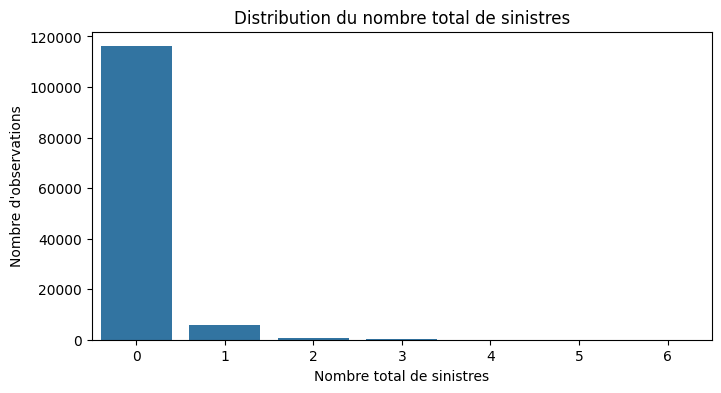

In [82]:
plt.figure(figsize=(8, 4))

sns.countplot(x=total_nclaims)

plt.title("Distribution du nombre total de sinistres")
plt.xlabel("Nombre total de sinistres")
plt.ylabel("Nombre d'observations")
plt.show()

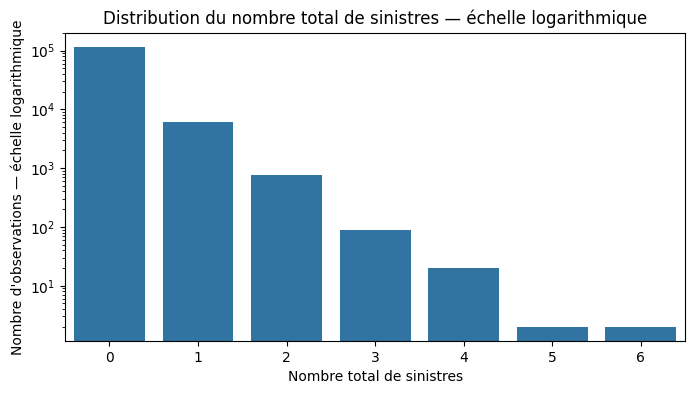

In [83]:
plt.figure(figsize=(8, 4))

sns.countplot(x=total_nclaims)

plt.yscale("log")
plt.title("Distribution du nombre total de sinistres — échelle logarithmique")
plt.xlabel("Nombre total de sinistres")
plt.ylabel("Nombre d'observations — échelle logarithmique")
plt.show()

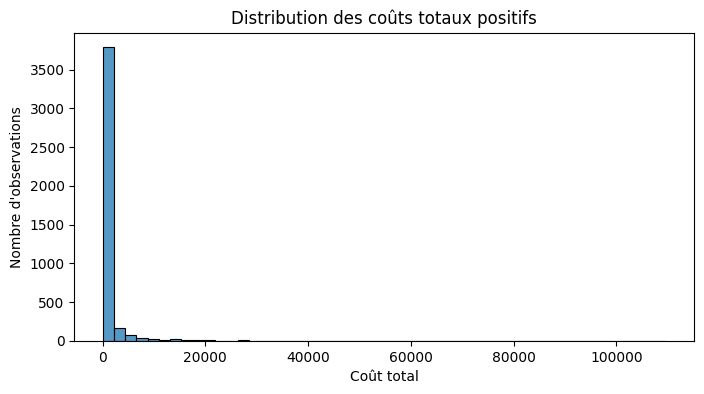

In [84]:
plt.figure(figsize=(8, 4))

sns.histplot(
    positive_total_claims,
    bins=50
)

plt.title("Distribution des coûts totaux positifs")
plt.xlabel("Coût total")
plt.ylabel("Nombre d'observations")
plt.show()

In [85]:
claim_limit_99 = positive_total_claims.quantile(0.99)

print(f"99 % des coûts positifs sont inférieurs à : {claim_limit_99:.2f}")

99 % des coûts positifs sont inférieurs à : 10584.11


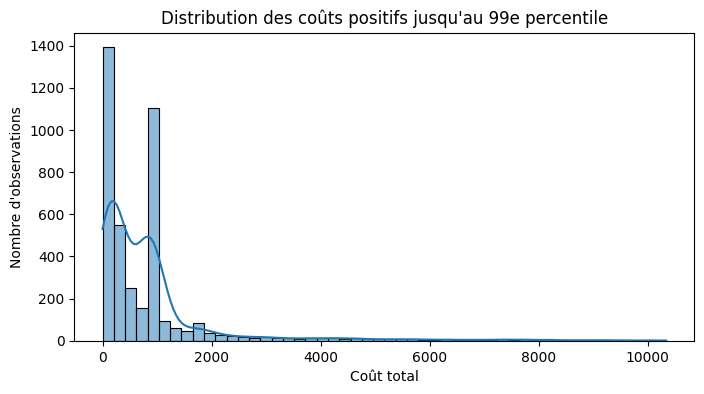

In [86]:
plt.figure(figsize=(8, 4))

sns.histplot(
    positive_total_claims[
        positive_total_claims <= claim_limit_99
    ],
    bins=50,
    kde=True
)

plt.title("Distribution des coûts positifs jusqu'au 99e percentile")
plt.xlabel("Coût total")
plt.ylabel("Nombre d'observations")
plt.show()

### Conclusion sur les sinistres

La majorité des observations ne présentent aucun sinistre, ce qui entraîne un fort déséquilibre de la future cible de classification.

Les montants positifs présentent une distribution fortement asymétrique : la majorité des sinistres possède un coût relativement limité, tandis que quelques sinistres atteignent des montants très élevés.

Cette structure justifie une modélisation séparée de la fréquence et de la sévérité. Les grands sinistres seront conservés, car ils jouent un rôle essentiel dans l’évaluation du risque extrême.

## 8. Analyse temporelle du portefeuille

Cette section étudie l’évolution du nombre de contrats et des sinistres au cours des cinq années d’observation.

In [87]:
observations_by_year = df["year"].value_counts().sort_index()

observations_by_year

year
1    40284
2    29818
3    22505
4    17044
5    13284
Name: count, dtype: int64

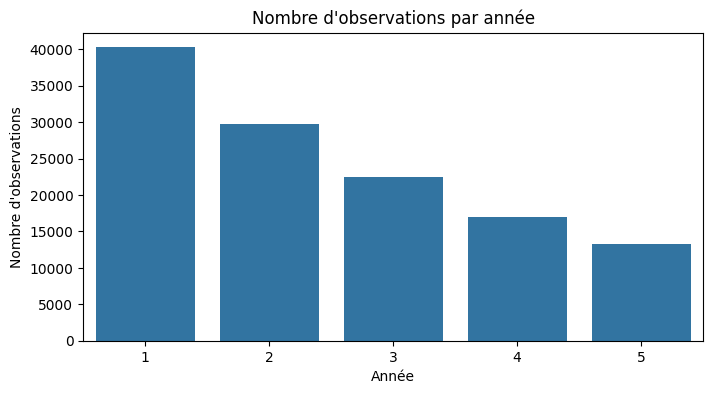

In [88]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=observations_by_year.index,
    y=observations_by_year.values
)

plt.title("Nombre d'observations par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'observations")
plt.show()

In [89]:
policies_by_year = df.groupby("year")["PolID"].nunique()

policies_by_year

year
1    40284
2    29818
3    22505
4    17044
5    13284
Name: PolID, dtype: int64

In [90]:
temporal_counts = pd.DataFrame({
    "Nombre_observations": observations_by_year,
    "Nombre_contrats": policies_by_year
})

temporal_counts

,Nombre_observations,Nombre_contrats
year,,
1,40284,40284
2,29818,29818
3,22505,22505
4,17044,17044
5,13284,13284


In [91]:
temporal_df = df.copy()

In [92]:
temporal_df["Total_NClaims"] = (
    temporal_df["NClaims1"]
    + temporal_df["NClaims2"]
)

temporal_df["Total_Claims"] = (
    temporal_df["Claims1"]
    + temporal_df["Claims2"]
)

temporal_df["Has_Claim"] = (
    temporal_df["Total_NClaims"] > 0
).astype(int)

In [94]:
annual_summary = temporal_df.groupby("year").agg(
    Nombre_observations=("PolID", "size"),
    Nombre_contrats=("PolID", "nunique"),
    Nombre_total_sinistres=("Total_NClaims", "sum"),
    Cout_total_sinistres=("Total_Claims", "sum"),
    Taux_sinistre=("Has_Claim", "mean")
)

annual_summary

,Nombre_observations,Nombre_contrats,Nombre_total_sinistres,Cout_total_sinistres,Taux_sinistre
year,,,,,
1,40284,40284,2685,1479835.70,0.058385
2,29818,29818,1990,1190689.53,0.057817
3,22505,22505,1498,829927.79,0.057321
4,17044,17044,982,448409.87,0.050692
5,13284,13284,703,273669.78,0.046673


In [95]:
annual_summary["Taux_sinistre"] = (
    annual_summary["Taux_sinistre"] * 100
)

annual_summary.round(2)

,Nombre_observations,Nombre_contrats,Nombre_total_sinistres,Cout_total_sinistres,Taux_sinistre
year,,,,,
1,40284,40284,2685,1479835.70,5.84
2,29818,29818,1990,1190689.53,5.78
3,22505,22505,1498,829927.79,5.73
4,17044,17044,982,448409.87,5.07
5,13284,13284,703,273669.78,4.67


In [96]:
annual_summary["Cout_moyen_par_observation"] = (
    annual_summary["Cout_total_sinistres"]
    / annual_summary["Nombre_observations"]
)

annual_summary.round(2)

,Nombre_observations,Nombre_contrats,Nombre_total_sinistres,Cout_total_sinistres,Taux_sinistre,Cout_moyen_par_observation
year,,,,,,
1,40284,40284,2685,1479835.70,5.84,36.74
2,29818,29818,1990,1190689.53,5.78,39.93
3,22505,22505,1498,829927.79,5.73,36.88
4,17044,17044,982,448409.87,5.07,26.31
5,13284,13284,703,273669.78,4.67,20.60


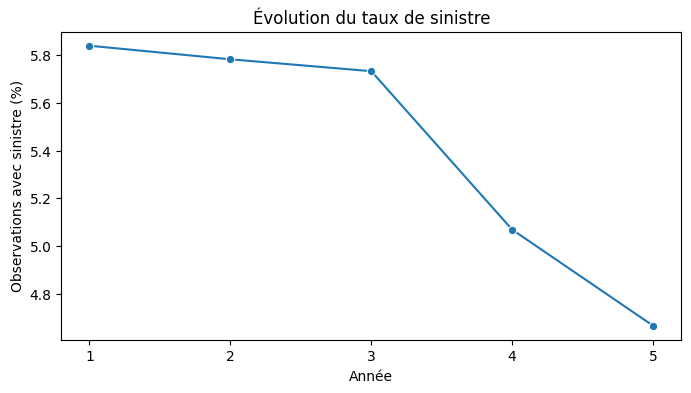

In [97]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=annual_summary,
    x=annual_summary.index,
    y="Taux_sinistre",
    marker="o"
)

plt.title("Évolution du taux de sinistre")
plt.xlabel("Année")
plt.ylabel("Observations avec sinistre (%)")
plt.xticks(annual_summary.index)
plt.show()

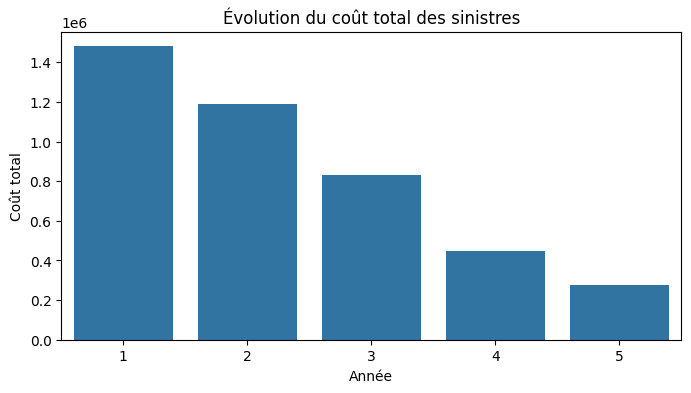

In [98]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=annual_summary,
    x=annual_summary.index,
    y="Cout_total_sinistres"
)

plt.title("Évolution du coût total des sinistres")
plt.xlabel("Année")
plt.ylabel("Coût total")
plt.show()

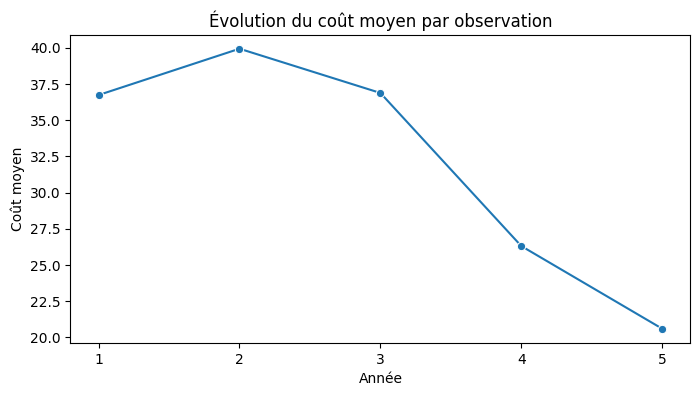

In [99]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=annual_summary,
    x=annual_summary.index,
    y="Cout_moyen_par_observation",
    marker="o"
)

plt.title("Évolution du coût moyen par observation")
plt.xlabel("Année")
plt.ylabel("Coût moyen")
plt.xticks(annual_summary.index)
plt.show()

## 9. Conclusion de la compréhension des données

Le dataset contient 122 935 observations et 22 variables. Il représente 40 284 contrats suivis sur une période maximale de cinq années.

Une observation correspond à un contrat identifié par `PolID` pendant une année donnée. La combinaison `PolID`–`year` est unique, ce qui confirme la structure longitudinale des données.

Aucune valeur manquante et aucune ligne complètement dupliquée n’ont été détectées. La variable `Unnamed: 0` correspond à un ancien index et devra être supprimée.

Les variables de sinistres sont fortement déséquilibrées : la majorité des observations ne possède aucun sinistre. Les montants des sinistres présentent également une forte asymétrie et quelques valeurs très élevées. Ces valeurs extrêmes seront conservées en raison de leur importance dans l’analyse du risque de queue.

Certaines observations possèdent un nombre de sinistres positif avec un montant nul. Elles seront conservées tant que leur caractère erroné n’est pas démontré par la documentation métier.

Le nombre de contrats diminue au fil des années. La dimension temporelle devra donc être respectée lors de la validation des modèles et de la simulation de l’apprentissage continu.

### Décisions pour la suite

- supprimer `Unnamed: 0` ;
- conserver `PolID` uniquement comme identifiant ;
- conserver `year` pour la validation temporelle ;
- créer `Total_NClaims`, `Total_Claims` et `Has_Claim` ;
- ne pas supprimer automatiquement les sinistres extrêmes ;
- préparer séparément les variables catégorielles et numériques ;
- éviter un découpage aléatoire qui ignorerait la structure temporelle ;
- modéliser séparément la fréquence et le coût des sinistres.